In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/clean/clean_data.csv")

### 1) ช่วงวัย ที่มี การ Order มากที่สุด ในปี 2023

In [26]:
order_per_ageGroup = (
    df[df["Year"] == 2023]
    .groupby("AgeGroup")["OrderID"]
    .nunique()
    .sort_values(ascending=False)
)

order_per_ageGroup_quantity = (
    df[df["Year"] == 2023]
    .groupby("AgeGroup")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

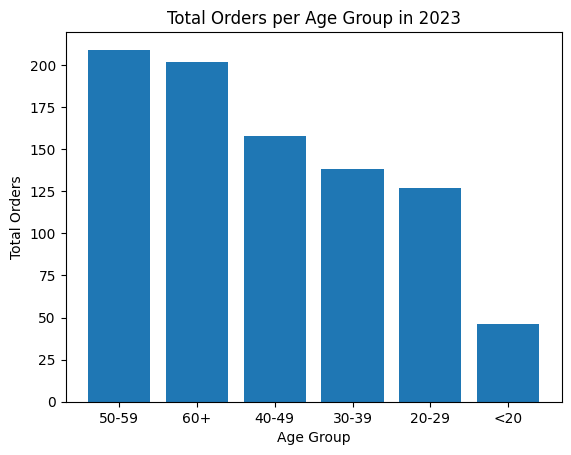

In [27]:
plt.bar(order_per_ageGroup.index, order_per_ageGroup.values)
plt.xlabel("Age Group")
plt.ylabel("Total Orders")
plt.title("Total Orders per Age Group in 2023")
plt.show()

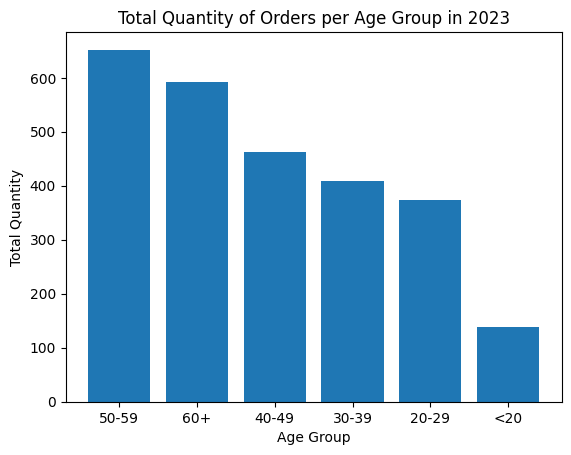

In [28]:
#Total Quantity per Age Group in 2023
plt.bar(order_per_ageGroup_quantity.index, order_per_ageGroup_quantity.values)
plt.xlabel("Age Group")
plt.ylabel("Total Quantity")
plt.title("Total Quantity of Orders per Age Group in 2023")
plt.show()

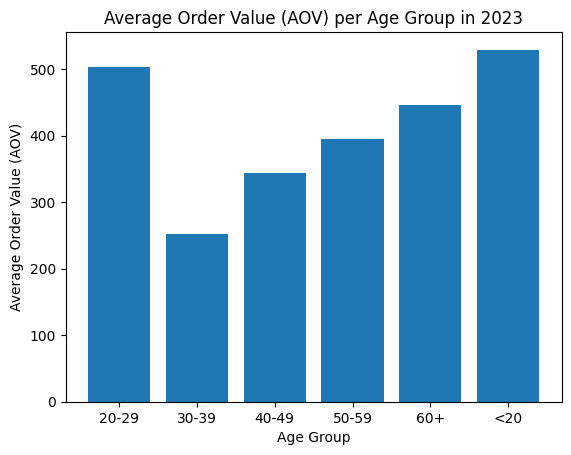

In [29]:
#AOV per Age Group in 2023
aov_per_ageGroup = (
    df[df["Year"] == 2023]
    .groupby("AgeGroup")["Revenue"]
    .sum()
    / df[df["Year"] == 2023]
    .groupby("AgeGroup")["OrderID"]
    .nunique()
)

plt.bar(aov_per_ageGroup.index, aov_per_ageGroup.values)
plt.xlabel("Age Group")
plt.ylabel("Average Order Value (AOV)")
plt.title("Average Order Value (AOV) per Age Group in 2023")
plt.show()

### 2) ช่วงวัย ที่มี การ Delivery(เก็บเงิน) มากที่สุด ในปี 2023

In [30]:
delivered_per_ageGroup = (
    df[(df["Year"] == 2023) & (df["Delivered"] == True)]
    .groupby("AgeGroup")["OrderID"]
    .nunique()
    .sort_values(ascending=False)
)

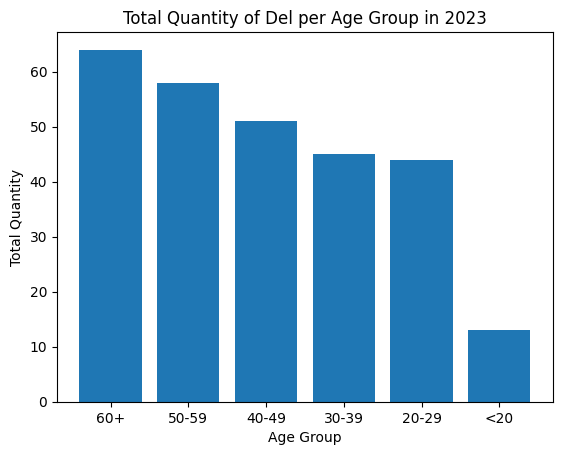

In [31]:
plt.bar(delivered_per_ageGroup.index, delivered_per_ageGroup.values)
plt.xlabel("Age Group")
plt.ylabel("Total Quantity")
plt.title("Total Quantity of Del per Age Group in 2023")
plt.show()

In [32]:
# หาว่า ทําไม 60 ซื้อมากสุด ทั้งที่มี Data set มากกว่า 50-59 มาก แต่ 60 กลับซื้อมากกว่า และ ค่าเฉลี่ยต่อหัว conversion rate ตํ่ากว่าด้วย

quantity_revenue_per_ageGroup = (
    df[(df["Year"] == 2023) & (df["Delivered"] == True)]
    .groupby("AgeGroup")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

print(quantity_revenue_per_ageGroup)

AgeGroup
60+      188
50-59    171
20-29    143
40-49    141
30-39    129
<20       43
Name: Quantity, dtype: int64


### Conversion Rate ต่อช่วงวัย ปี2023

In [33]:
conversion_rate = (
    delivered_per_ageGroup / order_per_ageGroup.replace(0, np.nan)
) * 100

In [34]:
print(conversion_rate)

AgeGroup
20-29    34.645669
30-39    32.608696
40-49    32.278481
50-59    27.751196
60+      31.683168
<20      28.260870
Name: OrderID, dtype: float64


##### วิเคราะห์ต่อยอด จากด้านบน

#### จำนวนลูกค้าในแต่ละกลุ่ม

In [35]:
df[df["Year"] == 2023].groupby("AgeGroup")["Customer ID"].nunique().sort_values(ascending=False)

AgeGroup
50-59    65
60+      60
40-49    51
20-29    47
30-39    45
<20      17
Name: Customer ID, dtype: int64

In [36]:
df[(df["Year"] == 2023) & (df["Delivered"] == True)] \
.groupby("AgeGroup")["Quantity"].mean().sort_values(ascending=False)

AgeGroup
<20      3.307692
20-29    3.250000
50-59    2.948276
60+      2.937500
30-39    2.866667
40-49    2.764706
Name: Quantity, dtype: float64

In [37]:
df[(df["Year"] == 2023) & (df["Delivered"] == True)] \
.groupby("AgeGroup")["Quantity"].sum().sort_values(ascending=False)

AgeGroup
60+      188
50-59    171
20-29    143
40-49    141
30-39    129
<20       43
Name: Quantity, dtype: int64

AgeGroup
20-29    27.559055
30-39    39.130435
40-49    25.316456
50-59    30.622010
60+      29.702970
<20      34.782609
Name: OrderID, dtype: float64


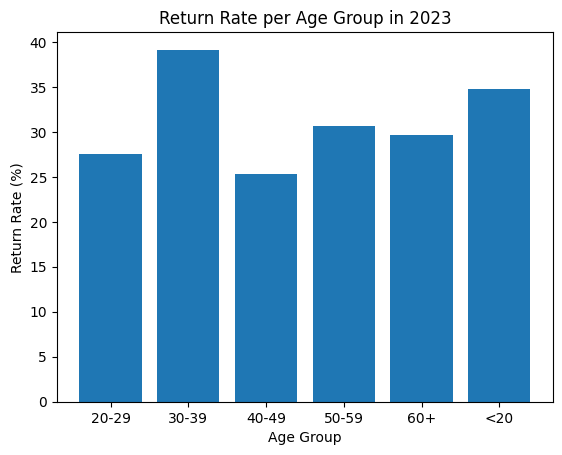

In [39]:
#Retrun Rate per Age Group in 2023
return_rate_per_ageGroup = (
    df[(df["Year"] == 2023) & (df["Shipping Status"] == "Returned")]
    .groupby("AgeGroup")["OrderID"]
    .nunique()
    / df[df["Year"] == 2023].groupby("AgeGroup")["OrderID"].nunique()
) * 100
print(return_rate_per_ageGroup)

plt.bar(return_rate_per_ageGroup.index, return_rate_per_ageGroup.values)
plt.xlabel("Age Group")
plt.ylabel("Return Rate (%)")
plt.title("Return Rate per Age Group in 2023")
plt.show()